# Final 4-Model Comparison

**Owner:** Advait Gujar (230911404) — shared evaluation utilities and the final comparison, reused across all four models.

> **Depends on:** `00_shared_pipeline.ipynb`, `01_mlp_baseline.ipynb`, `02_resnet18.ipynb`, `03_cnnlstm.ipynb` and `04_vit.ipynb` all run first, in the same kernel (needs `mlp_model`/`resnet_model`/`cnnlstm_model`/`vit_model` and their histories in memory).

## 14. Final Test-Set Evaluation (all 4 models)

In [1]:
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights)

_, mlp_auc, mlp_labels, mlp_preds = evaluate(mlp_model, test_loader, criterion)
_, resnet_auc, resnet_labels, resnet_preds = evaluate(resnet_model, test_loader, criterion)
_, cnnlstm_auc, cnnlstm_labels, cnnlstm_preds = evaluate(cnnlstm_model, test_loader, criterion)
_, vit_auc, vit_labels, vit_preds = evaluate(vit_model, test_loader, criterion)

test_labels = mlp_labels  # identical across models — same test_loader, same order

print(f"MLP       mean test AUC: {mlp_auc:.4f}")
print(f"ResNet18  mean test AUC: {resnet_auc:.4f}")
print(f"CNN-LSTM  mean test AUC: {cnnlstm_auc:.4f}")
print(f"ViT       mean test AUC: {vit_auc:.4f}")

MLP       mean test AUC: 0.6608
ResNet18  mean test AUC: 0.8043
CNN-LSTM  mean test AUC: 0.6743
ViT       mean test AUC: 0.8041


## 15. Plot: Loss and AUC Curves (all 4 models, train + val)

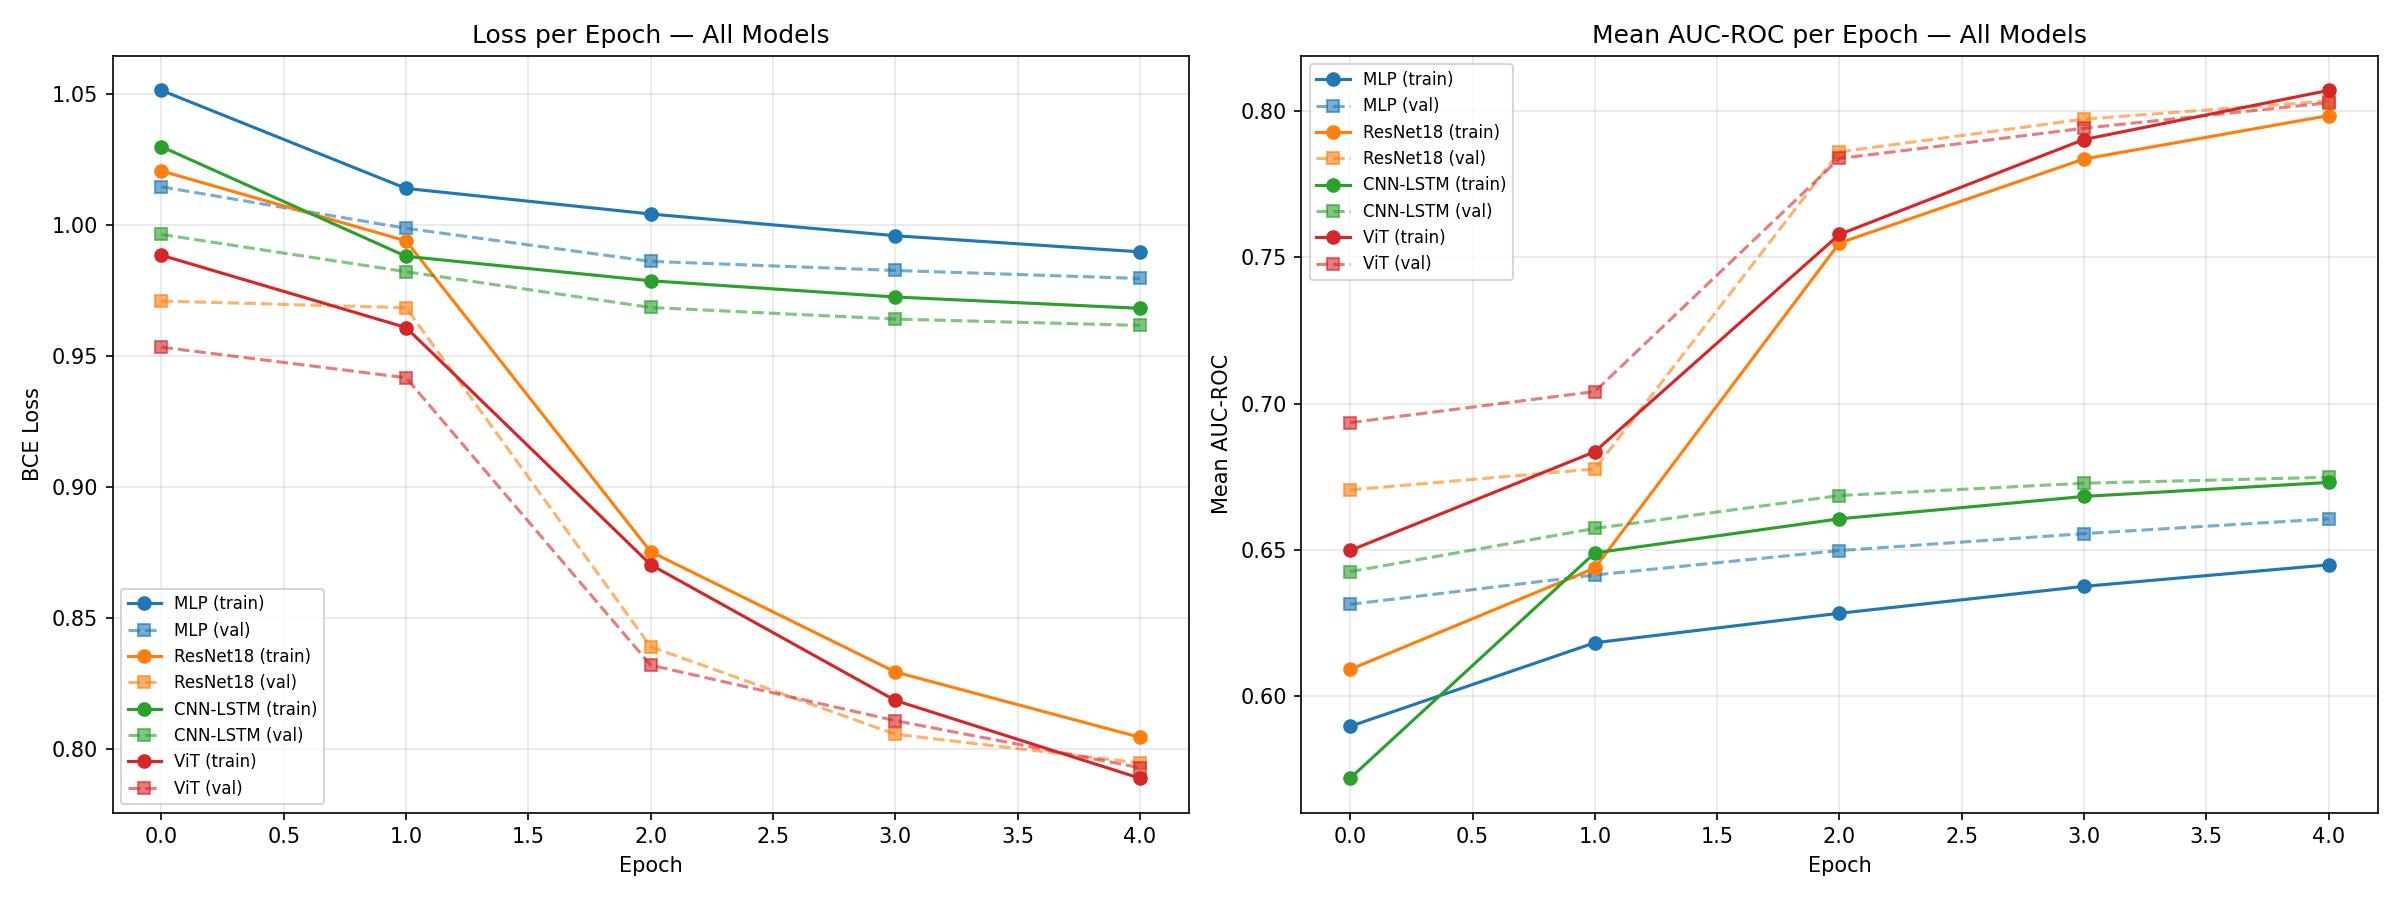

In [2]:
colors = {'MLP': 'tab:blue', 'ResNet18': 'tab:orange', 'CNN-LSTM': 'tab:green', 'ViT': 'tab:red'}
histories = {'MLP': mlp_history, 'ResNet18': resnet_history, 'CNN-LSTM': cnnlstm_history, 'ViT': vit_history}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for name, hist in histories.items():
    axes[0].plot(hist['train_loss'], marker='o', label=f'{name} (train)', color=colors[name])
    axes[0].plot(hist['val_loss'], marker='s', linestyle='--', label=f'{name} (val)', color=colors[name], alpha=0.6)
axes[0].set_title('Loss per Epoch — All Models')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('BCE Loss')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

for name, hist in histories.items():
    axes[1].plot(hist['train_auc'], marker='o', label=f'{name} (train)', color=colors[name])
    axes[1].plot(hist['val_auc'], marker='s', linestyle='--', label=f'{name} (val)', color=colors[name], alpha=0.6)
axes[1].set_title('Mean AUC-ROC per Epoch — All Models')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Mean AUC-ROC')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'loss_auc_curves.png'), dpi=150)
plt.show()

## 16. Plot: ROC Curves (all 4 models, one graph)

Micro-averaged across all 5 diseases x all test samples — collapses each
model to a single representative curve, since a true per-disease-per-model
breakdown (5 x 4 = 20 lines) would be unreadable on one plot.


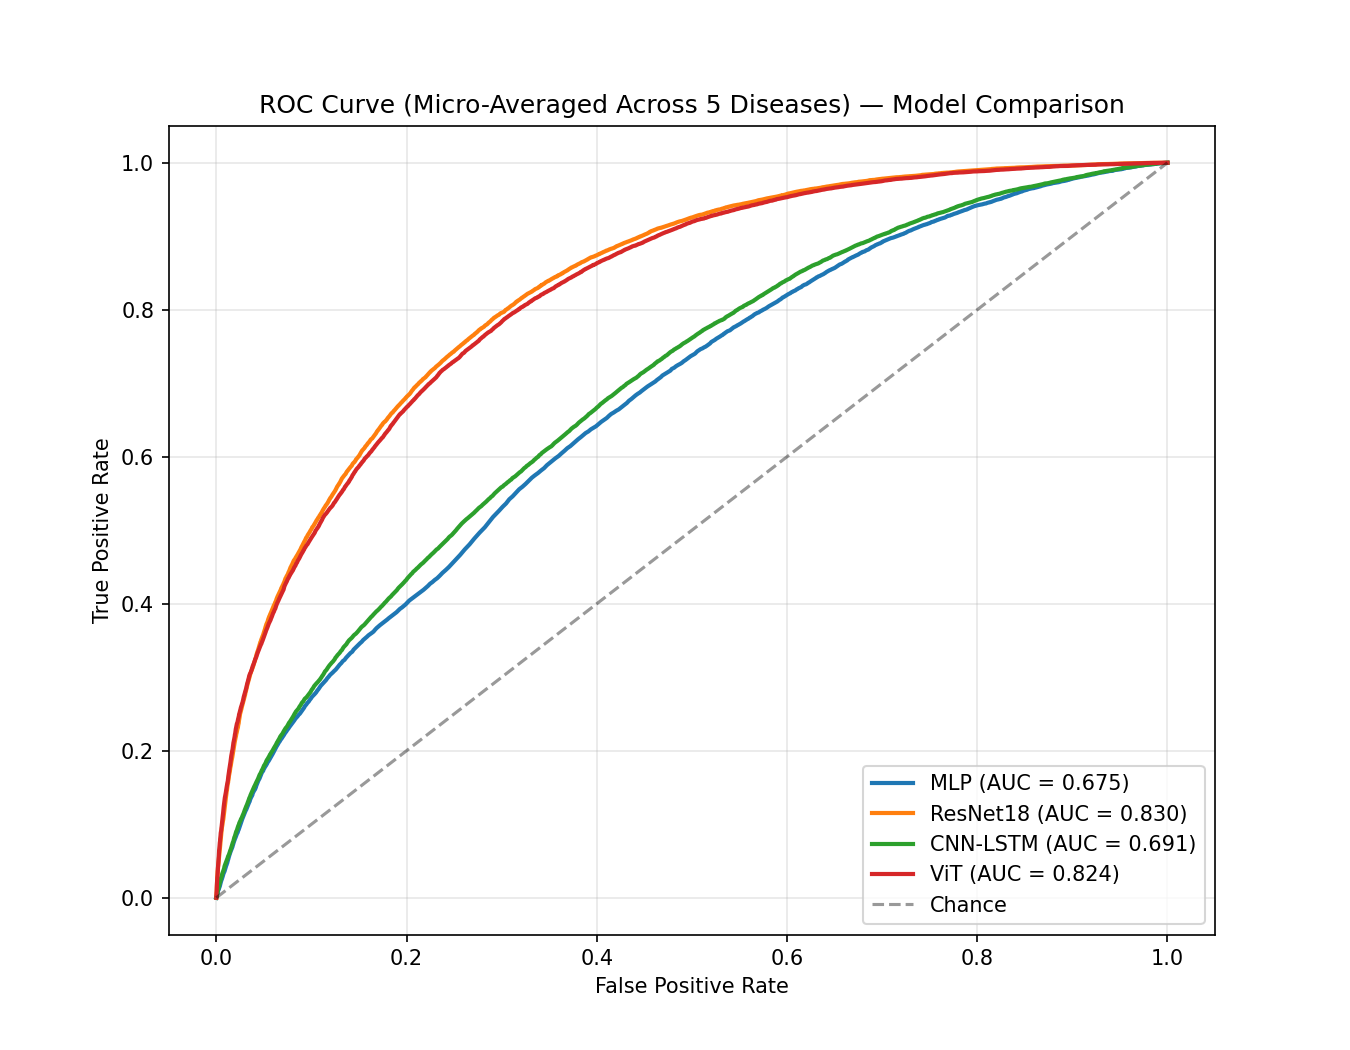

In [3]:
model_preds = {'MLP': mlp_preds, 'ResNet18': resnet_preds, 'CNN-LSTM': cnnlstm_preds, 'ViT': vit_preds}

plt.figure(figsize=(9, 7))
for name, preds in model_preds.items():
    fpr, tpr, _ = roc_curve(test_labels.ravel(), preds.ravel())
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})', color=colors[name], linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Chance')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Micro-Averaged Across 5 Diseases) — Model Comparison')
plt.legend(loc='lower right'); plt.grid(alpha=0.3)
plt.savefig(os.path.join(OUTPUT_DIR, 'roc_comparison.png'), dpi=150)
plt.show()

## 17. Plot: Precision-Recall Curves (all 4 models, one graph)

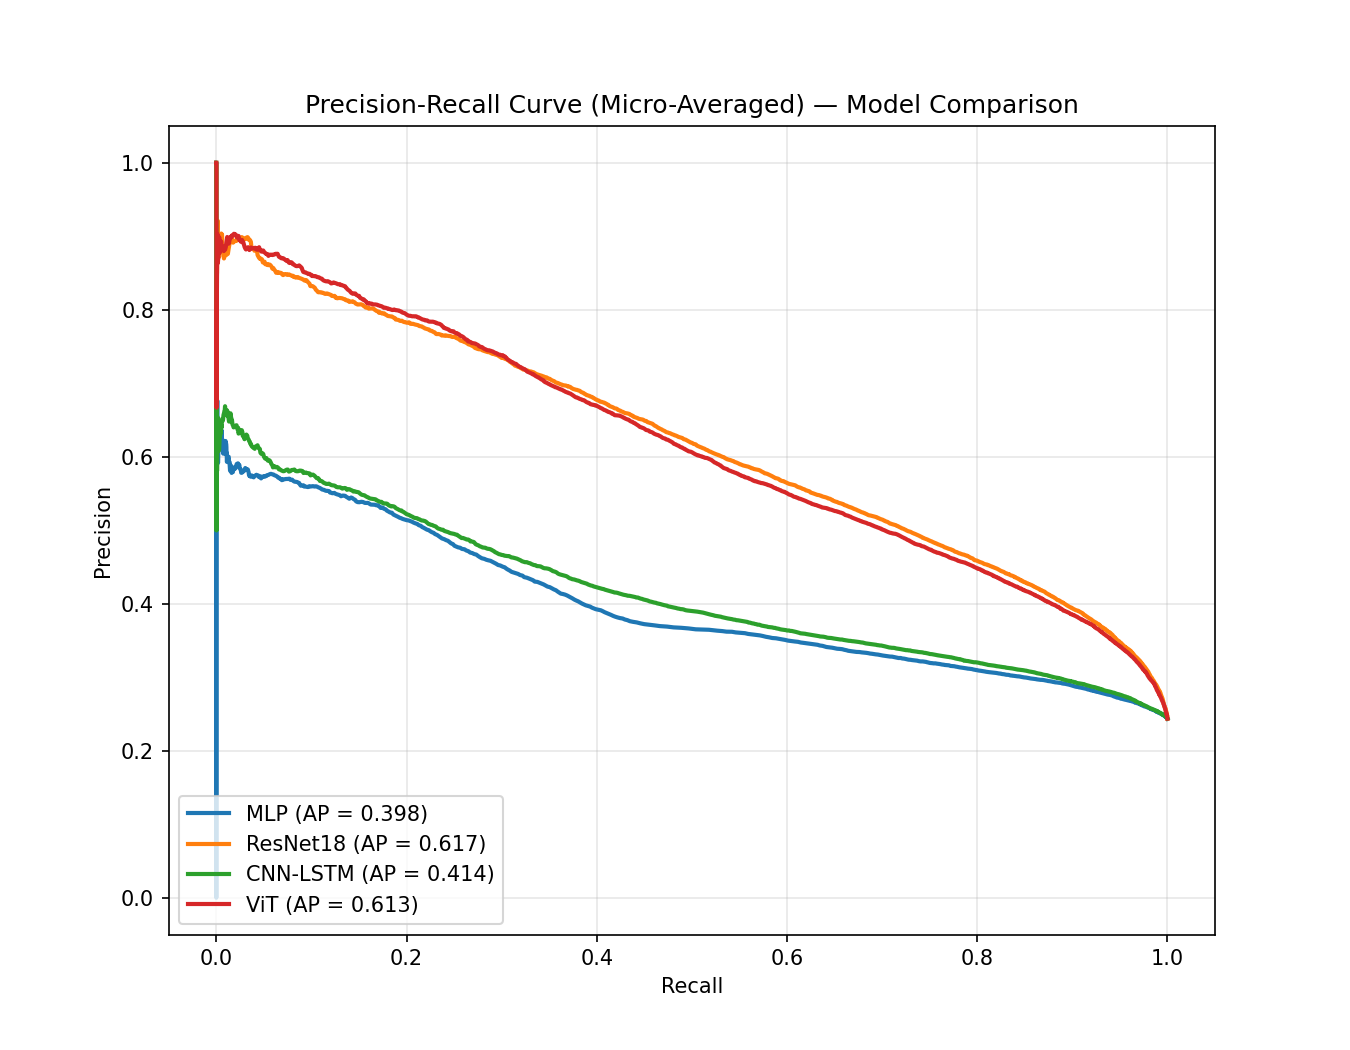

In [4]:
plt.figure(figsize=(9, 7))
for name, preds in model_preds.items():
    precision, recall, _ = precision_recall_curve(test_labels.ravel(), preds.ravel())
    ap = average_precision_score(test_labels, preds, average='micro')
    plt.plot(recall, precision, label=f'{name} (AP = {ap:.3f})', color=colors[name], linewidth=2)

plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Micro-Averaged) — Model Comparison')
plt.legend(loc='lower left'); plt.grid(alpha=0.3)
plt.savefig(os.path.join(OUTPUT_DIR, 'pr_comparison.png'), dpi=150)
plt.show()

## 18. Per-Disease AUC-ROC Breakdown (all 4 models)

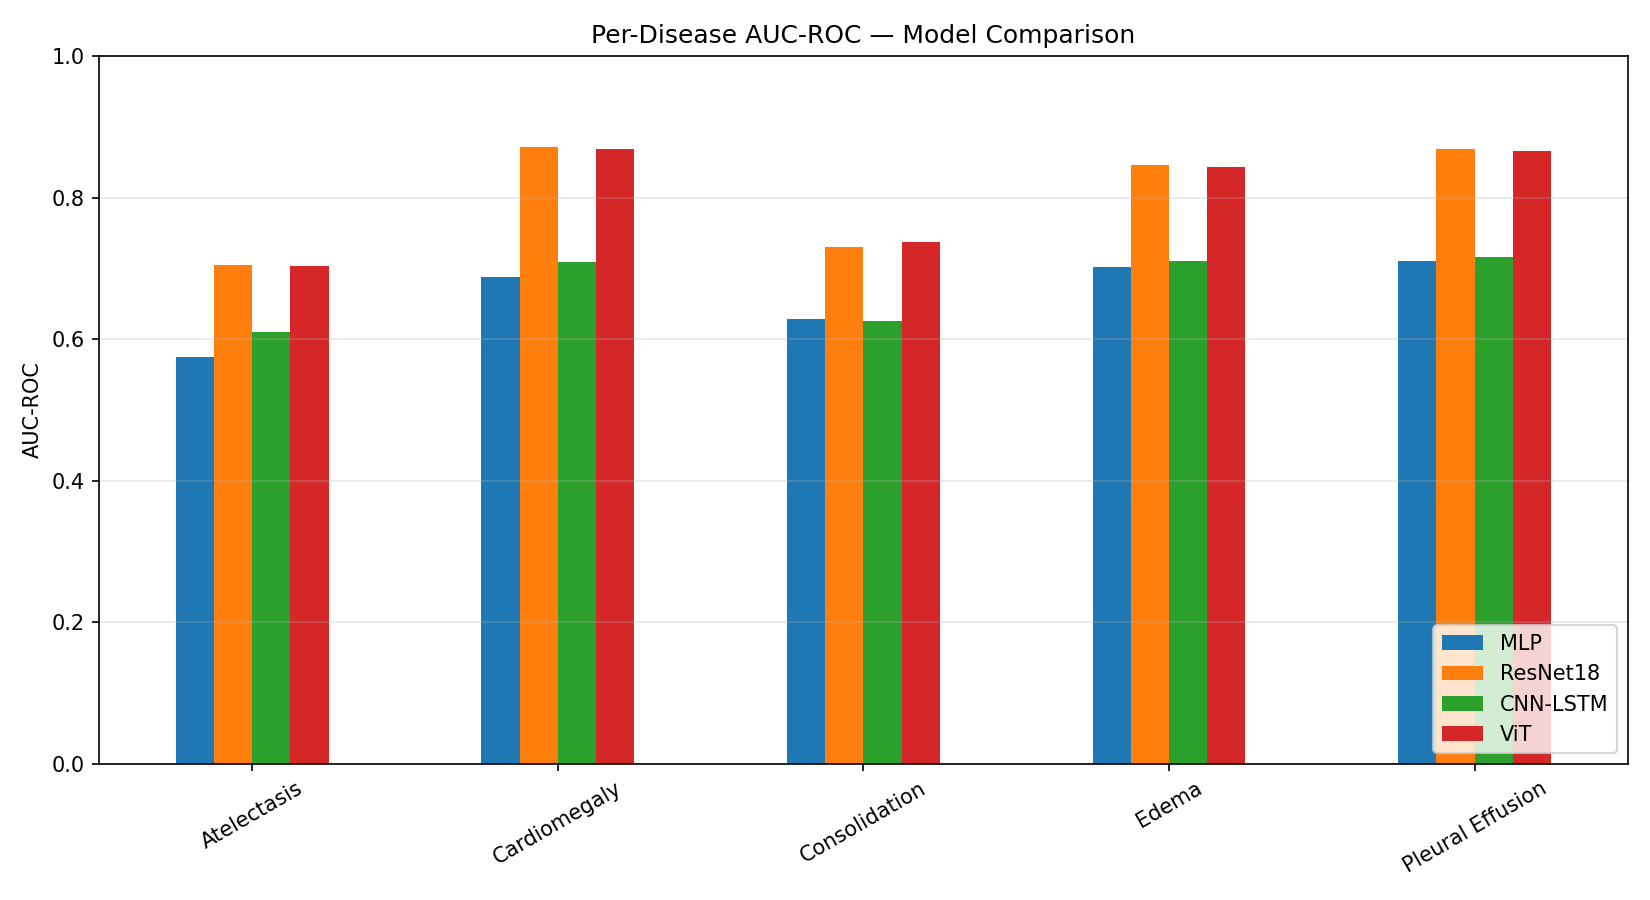

In [5]:
per_disease_results = {}
for name, (labels, preds) in {
    'MLP': (mlp_labels, mlp_preds),
    'ResNet18': (resnet_labels, resnet_preds),
    'CNN-LSTM': (cnnlstm_labels, cnnlstm_preds),
    'ViT': (vit_labels, vit_preds),
}.items():
    per_disease_results[name] = _per_disease_auc(labels, preds)

per_disease_df = pd.DataFrame(per_disease_results, index=DISEASE_COLS)
print(per_disease_df.round(4))

fig, ax = plt.subplots(figsize=(11, 6))
per_disease_df.plot(kind='bar', ax=ax, rot=30)
ax.set_title('Per-Disease AUC-ROC — Model Comparison')
ax.set_ylabel('AUC-ROC'); ax.set_ylim(0, 1.0)
ax.legend(loc='lower right'); ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'per_disease_auc.png'), dpi=150)
plt.show()

## 19. Final Comparison Table (Accuracy-equivalent metrics at threshold 0.5)

              MLP  ResNet18  CNN-LSTM     ViT
Mean AUC-ROC       0.6608    0.8043    0.6743  0.8041
Precision (micro)  0.3218    0.4474    0.3368  0.4495
Recall (micro)     0.7389    0.8214    0.7253  0.7979
F1 (micro)         0.4484    0.5793    0.4600  0.5750


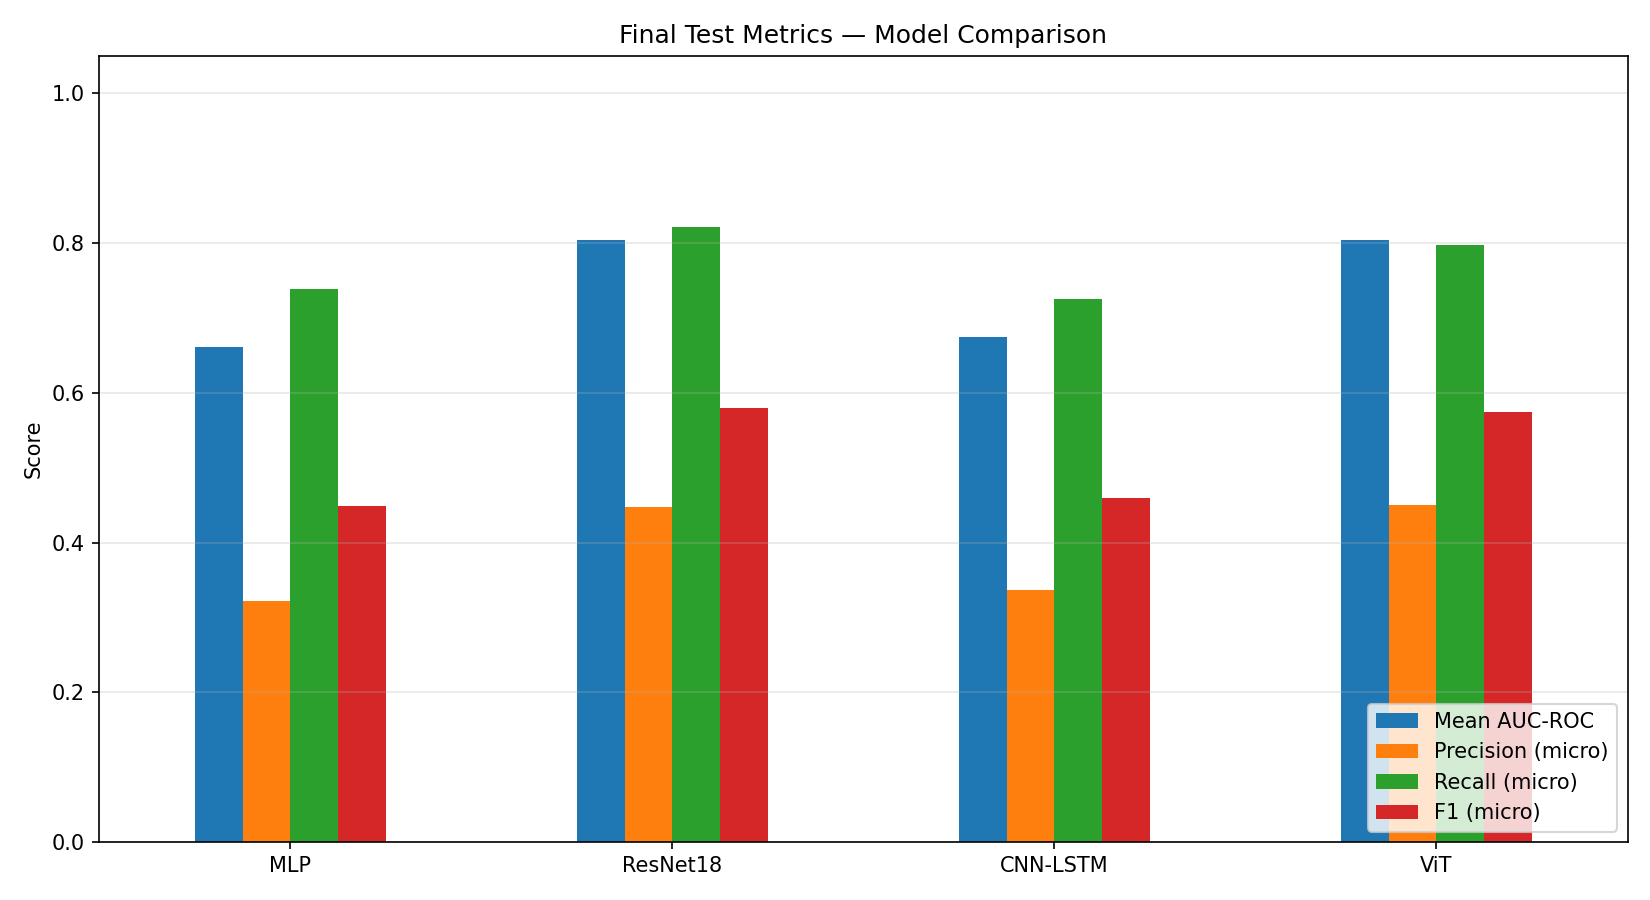

In [6]:
def multilabel_metrics(labels, preds, threshold=0.5):
    binary_preds = (preds >= threshold).astype(int)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, binary_preds, average='micro', zero_division=0
    )
    mean_auc = np.mean(_per_disease_auc(labels, preds))
    return mean_auc, precision, recall, f1

results = pd.DataFrame({
    'MLP':      multilabel_metrics(mlp_labels, mlp_preds),
    'ResNet18': multilabel_metrics(resnet_labels, resnet_preds),
    'CNN-LSTM': multilabel_metrics(cnnlstm_labels, cnnlstm_preds),
    'ViT':      multilabel_metrics(vit_labels, vit_preds),
}, index=['Mean AUC-ROC', 'Precision (micro)', 'Recall (micro)', 'F1 (micro)'])

print(results.round(4))
results.to_csv(os.path.join(OUTPUT_DIR, 'model_comparison.csv'))

fig, ax = plt.subplots(figsize=(11, 6))
results.T.plot(kind='bar', ax=ax, rot=0)
ax.set_title('Final Test Metrics — Model Comparison')
ax.set_ylabel('Score'); ax.set_ylim(0, 1.05)
ax.legend(loc='lower right'); ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'metrics_comparison.png'), dpi=150)
plt.show()

## 20. Confusion Matrices

Multi-label doesn't have one natural confusion matrix per model (5 diseases x
2 classes each). We show a **flattened micro confusion matrix** per model
(treating every disease-label decision across every test image as one binary
classification instance) — the same micro-averaging principle used for the
ROC/PR curves above, applied consistently.


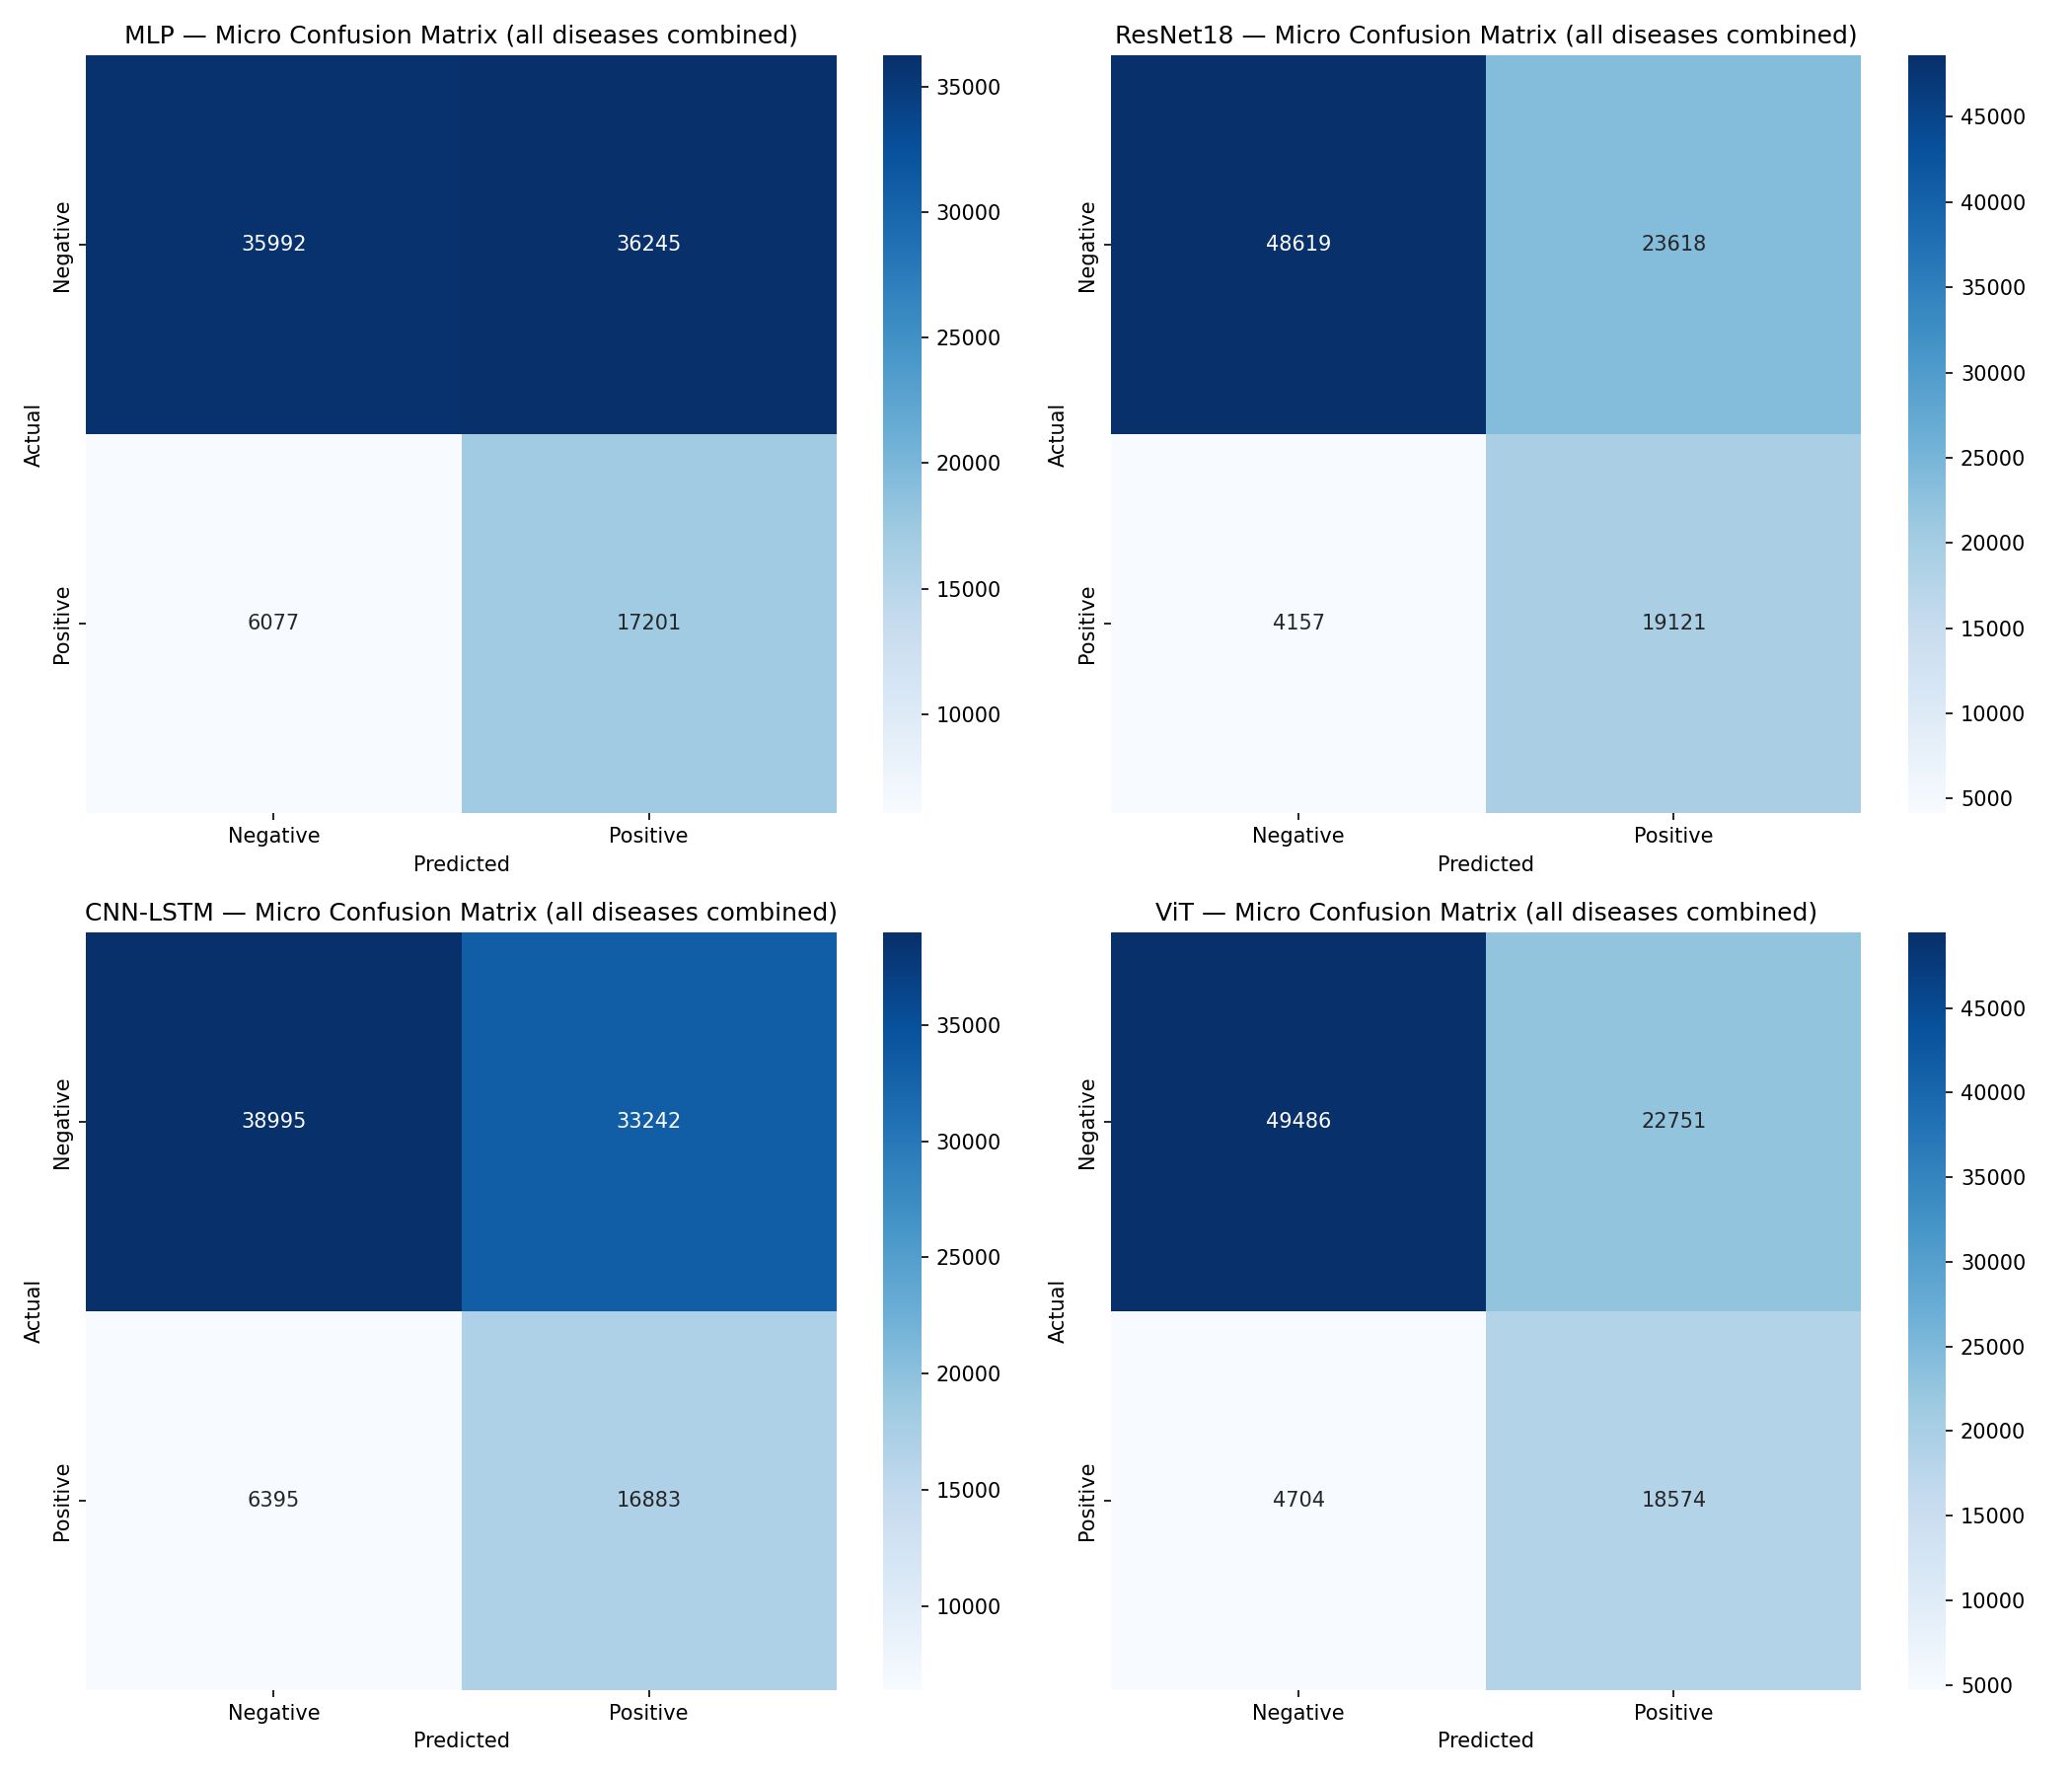


All outputs saved to: D:\Projects\ChestXray-Academic-Comparison\outputs


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
model_data = {'MLP': (mlp_labels, mlp_preds), 'ResNet18': (resnet_labels, resnet_preds),
              'CNN-LSTM': (cnnlstm_labels, cnnlstm_preds), 'ViT': (vit_labels, vit_preds)}

for ax, (name, (labels, preds)) in zip(axes.flat, model_data.items()):
    binary_preds = (preds >= 0.5).astype(int)
    cm = confusion_matrix(labels.ravel(), binary_preds.ravel())
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'], ax=ax)
    ax.set_title(f'{name} — Micro Confusion Matrix (all diseases combined)')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrices.png'), dpi=150)
plt.show()

print(f"\nAll outputs saved to: {OUTPUT_DIR}")